# Evaluación 1

**Integrante 1:** Alan Jean Franco Fica Contreras

**Integrante 2:** Isaac Emmanuel Ponce Peña

**Integrante 3:** Kevin Jeremias Michel Romero Nograro

**Correo Electrónico integrante 1:** alan.fica2101@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** isaac.ponce2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** kevin.romero2201@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)
- scikit-learn (>=1.2.0)
- seaborn (>=0.12.0)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
```

# Carga de datos

In [32]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 04:27:34--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv.1’

dataset_churn_dirty 100%[===================>]   2.64M  --.-KB/s    in 0.04s   

2026-04-17 04:27:35 (66.2 MB/s) - ‘dataset_churn_dirty.csv.1’ saved [2771759/2771759]



In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
import os

from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder

In [34]:
# Carga el set de datos
data = pd.read_csv('dataset_churn_dirty.csv')

In [35]:
data.shape

(21000, 16)

# Revisión de valores nulos o faltantes

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

In [37]:
# Conteo absoluto y porcentual de valores nulos por columna
nulos = data.isnull().sum()
porcentaje_nulos = (nulos / len(data) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})
resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

,Nulos,Porcentaje (%)
gender,1053,5.01
payment_method,1047,4.99
monthly_income,1038,4.94
age,1036,4.93


**Comentario:** Se identificaron valores nulos en varias columnas del dataset, tanto en variables numéricas como categóricas. Para las variables numéricas se aplicará imputación por mediana, ya que esta medida es más robusta frente a la presencia de valores atípicos. Para las variables categóricas se utilizará la moda (valor más frecuente), preservando así la distribución original de cada categoría.

# Revisión de atípicos

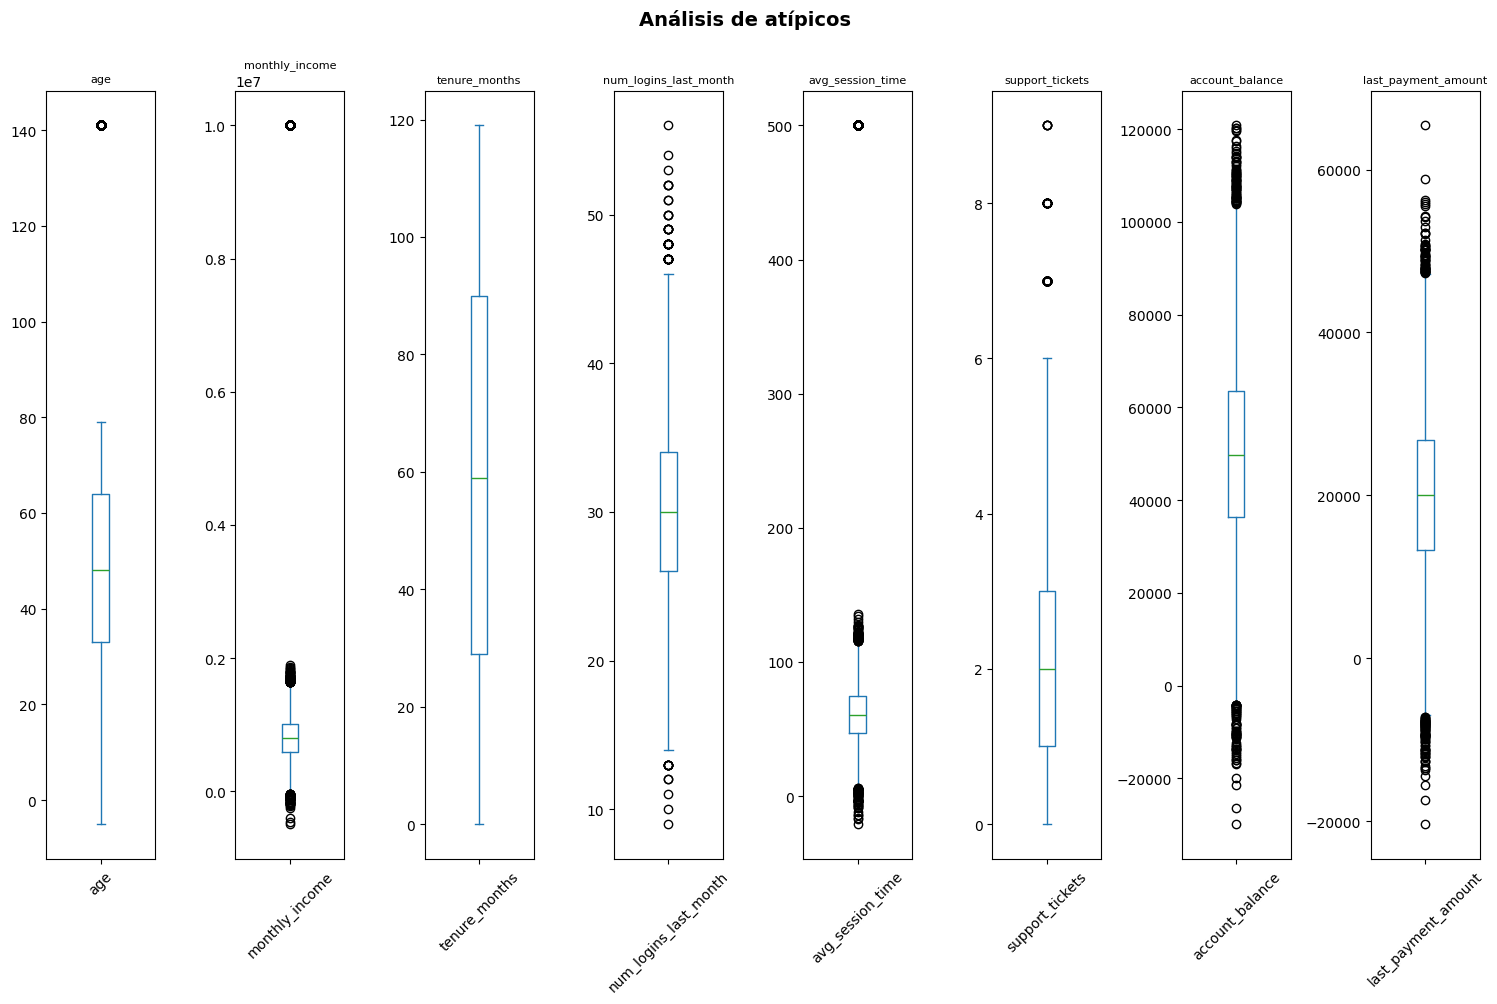

In [38]:
revision_atipicos = ['age', 'monthly_income', 'tenure_months', 'num_logins_last_month',
                     'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount']
fig, axes = plt.subplots(1, 8, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis='x', labelrotation=45)

plt.suptitle('Análisis de atípicos', fontsize=14, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

**Comentario:** Los graficos revelan la presencia de valores atípicos en varias variables numéricas. Se observan valores extremos especialmente en `monthly_income`, `account_balance` y `last_payment_amount`. Estos atípicos serán tratados (recorte en los percentiles 5% y 95%)

# Revisión de inconsistencias

**Reglas de negocio para la detección de inconsistencias:**

- `age`: debe ser un valor entre 1 y 105 años. Edades menores o iguales a 0 o mayores a 105 son imposibles.
- `monthly_income`: debe ser mayor o igual a 0. Un ingreso negativo carece de sentido.
- `tenure_months`: debe ser mayor o igual a 0. No se puede tener antigüedad negativa.
- `num_logins_last_month`: debe ser mayor o igual a 0. No puede haber accesos negativos.
- `avg_session_time`: debe ser mayor o igual a 0. No existen sesiones de duración negativa.
- `support_tickets`: debe ser mayor o igual a 0. No puede haber tickets negativos.
- `account_balance`: debe ser mayor o igual a 0. Un saldo negativo no es válido en este contexto.
- `last_payment_amount`: debe ser mayor o igual a 0. Un pago negativo no corresponde.
- Variables categóricas: solo deben aceptar los valores definidos en la metadata del dataset.

In [39]:
# Inconsistencias en variables numéricas
inconsistentes = data[
    ((data['age'] <= 0) | (data['age'] > 105)) |
    (data['monthly_income'] < 0) |
    (data['tenure_months'] < 0) |
    (data['num_logins_last_month'] < 0) |
    (data['avg_session_time'] < 0) |
    (data['support_tickets'] < 0) |
    (data['account_balance'] < 0) |
    (data['last_payment_amount'] < 0)
]
print(f"Registros con inconsistencias numéricas: {len(inconsistentes)}")
display(inconsistentes)

Registros con inconsistencias numéricas: 1346


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
24,25,141.0,4.947750e+05,9,23,80.627878,2,92214.081686,37054.981204,Male,Enterprise,East,Transfer,Yes,Mobile,1
47,48,38.0,9.393170e+05,119,28,51.699977,3,71143.120322,-8638.523066,NaN,Premium,North,Debit Card,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
59,60,38.0,6.602348e+05,9,34,47.909770,2,71055.533036,-707.350603,Male,Enterprise,East,Debit Card,No,Tablet,0
62,63,77.0,NaN,37,25,77.341020,4,-3484.853555,19584.816007,Female,Enterprise,West,PayPal,No,Tablet,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0
20922,7271,31.0,7.601867e+05,17,44,67.498106,1,56370.726597,-1097.518661,Female,Premium,East,Transfer,Yes,Mobile,1
20926,7888,63.0,4.528124e+05,26,45,107.170665,3,41752.594619,-1682.760110,Other,Premium,West,PayPal,Yes,Desktop,1
20927,15710,74.0,-1.000000e+05,78,39,29.099820,0,61893.441053,33285.361859,Other,Enterprise,North,PayPal,No,Mobile,0


In [61]:
data.gender.unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

In [62]:
data.subscription_type.unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

In [63]:
data.region.unique()

array(['West', 'South', 'North', 'East'], dtype=object)

In [64]:
data.payment_method.unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

In [65]:
data.is_active.unique()

array(['Yes', 'No'], dtype=object)

In [67]:
data.churn.unique()

array([1, 0])

In [40]:
# Inconsistencias en variables categóricas
valores_esperados = {
    'gender': ['Male', 'Female', 'Other'],
    'subscription_type': ['Basic', 'Premium', 'Enterprise'],
    'region': ['North', 'South', 'East', 'West'],
    'payment_method': ['Credit Card', 'Debit Card', 'PayPal', 'Transfer'],
    'is_active': ['Yes', 'No'],
    'preferred_device': ['Mobile', 'Desktop', 'Tablet']
}

for col, valores in valores_esperados.items():
    valores_unicos = data[col].dropna().unique()
    invalidos = [v for v in valores_unicos if v not in valores]
    if invalidos:
        print(f"  {col}: valores no esperados = {invalidos}")
    else:
        print(f"  {col}: sin inconsistencias")

  gender: sin inconsistencias
  subscription_type: sin inconsistencias
  region: sin inconsistencias
  payment_method: sin inconsistencias
  is_active: sin inconsistencias
  preferred_device: sin inconsistencias
  gender: sin inconsistencias
  subscription_type: sin inconsistencias
  region: sin inconsistencias
  payment_method: sin inconsistencias
  is_active: sin inconsistencias
  preferred_device: sin inconsistencias


**Comentario:** En las variables numéricas se detectaron registros con valores fuera de los rangos lógicos. En las variables categóricas se verificó que los valores presentes correspondieran exactamente a los esperados según la metadata.

# Revisión de duplicados

In [41]:
data.duplicated().sum()

np.int64(1000)

In [42]:
# Mostrar los registros duplicados
data[data.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19989,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


**Comentario:** Se identificaron registros duplicados en el dataset. Estos serán eliminados en la etapa de limpieza para asegurarnos que no exista duplicidad de datos

# Limpieza y transformación

A continuación se define el pipeline completo de limpieza y transformación. El proceso sigue los siguientes pasos en orden:

1. **Eliminación de duplicados** — se eliminan filas completamente repetidas.
2. **recorte de datos** — se recortan los valores atípicos de las variables numéricas entre el percentil 5% y 95%.
3. **limpieza y transformación de datos** — se aplica un sistema paso a paso para preparar la información:
   - *Numéricas*: rellenamos los valores faltantes por la mediana + estandarización con `StandardScaler`.
   - *Categóricas nominales*: rellenamos los valores faltantes por la moda + codificación `OneHotEncoder`.
   - *Categóricas ordinales*: rellenamos los valores faltantes por la moda + las convertimos en números que respetan estrictamente su nivel de importancia.

In [43]:
# --- Transformador personalizado: Winsorización ---
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Recorta los valores de cada columna entre los percentiles
    lower_limit y (1 - upper_limit). Por defecto usa 5% y 95%.
    """
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_).astype('float64')
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_ if input_features is None else input_features)

In [44]:
# --- Transformador personalizado: Eliminación de duplicados ---
class EliminadorDuplicados(BaseEstimator, TransformerMixin):
    """Elimina filas completamente duplicadas del DataFrame."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop_duplicates().reset_index(drop=True)

In [45]:
# --- Feature Engineering: creación de nuevas variables ---
class FeatureEngineering(BaseEstimator, TransformerMixin):
    """
    Crea dos nuevas variables:
    - engagement_rate: logins por mes dividido por los meses de antigüedad.
      Representa qué tan activo es el cliente en relación a su tiempo en la plataforma.
    - income_balance_ratio: relación entre el saldo de la cuenta y el ingreso mensual.
      Indica la capacidad económica relativa del cliente.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Variable 1: tasa de engagement (logins / antigüedad)
        X['engagement_rate'] = X['num_logins_last_month'] / (X['tenure_months'].replace(0, 1))
        # Variable 2: relación saldo / ingreso mensual
        X['income_balance_ratio'] = X['account_balance'] / (X['monthly_income'].replace(0, 1))
        return X

In [46]:
set_config(transform_output='pandas')

In [47]:
numeric_features = ['age', 'monthly_income', 'tenure_months', 'num_logins_last_month',
                    'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount',
                    'engagement_rate', 'income_balance_ratio']

categorical_nominal = ['gender', 'region', 'payment_method', 'is_active', 'preferred_device']
categorical_ordinal = ['subscription_type']

In [48]:
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(limits=(0.05, 0.05))),
    ('scaler', StandardScaler())
])

In [49]:
pipeline_nominal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

In [50]:
pipeline_ordinal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Basic', 'Premium', 'Enterprise']]))
])

In [51]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numeric_features),
        ('cat_nom', pipeline_nominal, categorical_nominal),
        ('cat_ord', pipeline_ordinal, categorical_ordinal)
    ],
    remainder='passthrough',         # conserva customer_id y churn
    verbose_feature_names_out=False  # evita prefijos en los nombres de columnas
)

In [52]:
# Pipeline completo: duplicados → feature engineering → preprocesamiento
pipeline_limpieza = Pipeline(steps=[
    ('eliminar_duplicados', EliminadorDuplicados()),
    ('feature_engineering', FeatureEngineering()),
    ('preprocesamiento', preprocesador)
])

In [53]:
# Aplicar el pipeline completo al dataset original
data_clean = pipeline_limpieza.fit_transform(data)

# Limpiar prefijos residuales en los nombres de columnas
data_clean.columns = (
    data_clean.columns
    .str.replace('num__', '', regex=False)
    .str.replace('cat_nom__', '', regex=False)
    .str.replace('cat_ord__', '', regex=False)
    .str.replace('remainder__', '', regex=False)
)

print(f"Dimensiones originales : {data.shape}")
print(f"Dimensiones después del pipeline: {data_clean.shape}")

Dimensiones originales : (21000, 16)
Dimensiones después del pipeline: (20000, 24)


## Muestra del dataset transformado

In [54]:
# Primeras 5 filas del dataset limpio y transformado
display(data_clean.head())

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,engagement_rate,income_balance_ratio,...,region_West,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_Yes,preferred_device_Mobile,preferred_device_Tablet,subscription_type,customer_id,churn
0,-0.532803,0.000953,0.478751,1.819776,-1.627287,-1.462108,1.154006,1.794273,-0.376204,-0.212388,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1,1
1,1.180546,1.857161,-0.395436,-0.579494,-0.534592,0.753319,0.696641,0.669010,-0.348843,-0.582996,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1
2,-0.018798,0.409132,0.682728,-1.379250,-0.404769,-0.723633,-0.169151,-0.504737,-0.595827,-0.456194,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,3,0
3,1.637439,-0.011391,-0.424575,-1.379250,-0.291530,-0.723633,-1.503632,1.794273,-0.409301,-1.027108,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,4,1
4,0.209648,-1.277297,1.119822,-0.179615,0.383539,0.753319,0.468662,-0.579659,-0.580834,1.557898,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5,0


In [55]:
# Resumen estadístico del dataset transformado
data_clean.describe().round(3)

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,engagement_rate,income_balance_ratio,...,region_West,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_Yes,preferred_device_Mobile,preferred_device_Tablet,subscription_type,customer_id,churn
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,...,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,...,0.253,0.239,0.289,0.238,0.501,0.337,0.334,1.000,10000.500,0.302
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,0.435,0.427,0.454,0.426,0.500,0.473,0.472,0.818,5773.647,0.459
min,-1.618,-1.863,-1.561,-1.779,-1.777,-1.462,-1.783,-1.809,-0.629,-1.375,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
25%,-0.875,-0.701,-0.891,-0.779,-0.736,-0.724,-0.744,-0.738,-0.551,-0.695,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5000.750,0.000
50%,-0.019,0.001,-0.017,0.020,-0.014,0.015,-0.012,-0.001,-0.414,-0.212,...,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,10000.500,0.000
75%,0.838,0.705,0.887,0.820,0.731,0.753,0.738,0.746,0.007,0.451,...,1.000,0.000,1.000,0.000,1.000,1.000,1.000,2.000,15000.250,1.000
max,1.637,1.857,1.586,1.820,1.851,2.230,1.814,1.794,3.328,2.586,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,20000.000,1.000


**Comentario:** Las variables numéricas ahora tienen media aproximadamente 0 y desviación estándar 1, lo que confirma que la estandarización se aplicó correctamente. Las variables categóricas nominales fueron codificadas y la ordinal `subscription_type` con valores 0, 1, 2. Se incorporaron además las dos nuevas variables de ingeniería de características: `engagement_rate` e `income_balance_ratio`.

## Visualizaciones del proceso de limpieza y transformación

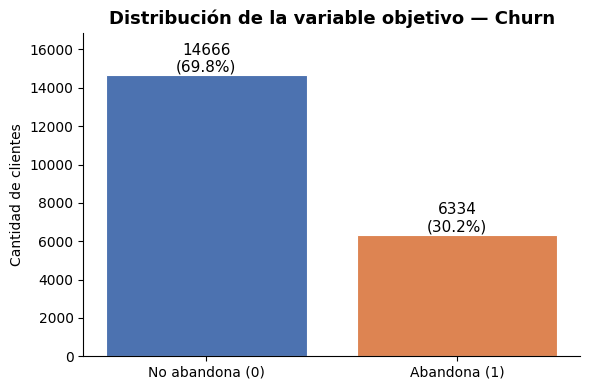

In [56]:
# --- Gráfico 1: Distribución de la variable objetivo (churn) ---
fig, ax = plt.subplots(figsize=(6, 4))
conteo = data['churn'].value_counts()
colores = ['#4C72B0', '#DD8452']
bars = ax.bar(['No abandona (0)', 'Abandona (1)'], conteo.values, color=colores, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}\n({val/len(data)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Distribución de la variable objetivo — Churn', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de clientes')
ax.set_ylim(0, conteo.max() * 1.15)
sb.despine()
plt.tight_layout()
plt.show()

**Comentario:** El gráfico muestra la distribución de la variable objetivo `churn`.

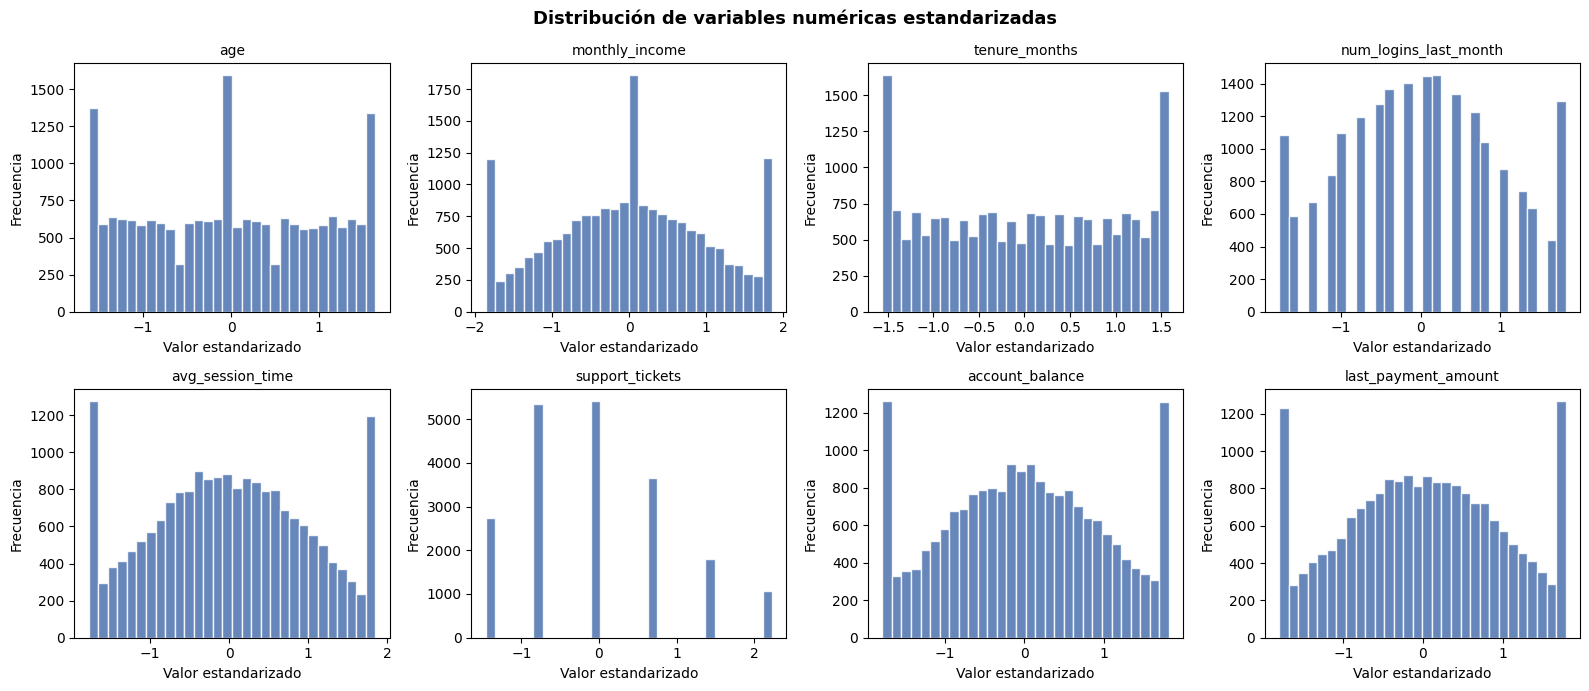

In [57]:
# --- Gráfico 2: Distribución de variables numéricas tras la estandarización ---
# Columnas numéricas originales (ya estandarizadas en data_clean)
cols_num_std = ['age', 'monthly_income', 'tenure_months', 'num_logins_last_month',
                'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(cols_num_std):
    axes[i].hist(data_clean[col].dropna(), bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valor estandarizado')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas estandarizadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Comentario:** Los gráficos muestran la distribución de las variables numéricas luego de aplicar el pipeline completo. Al estar estandarizadas (media ≈ 0, desviación ≈ 1), todas las variables se encuentran en la misma escala.

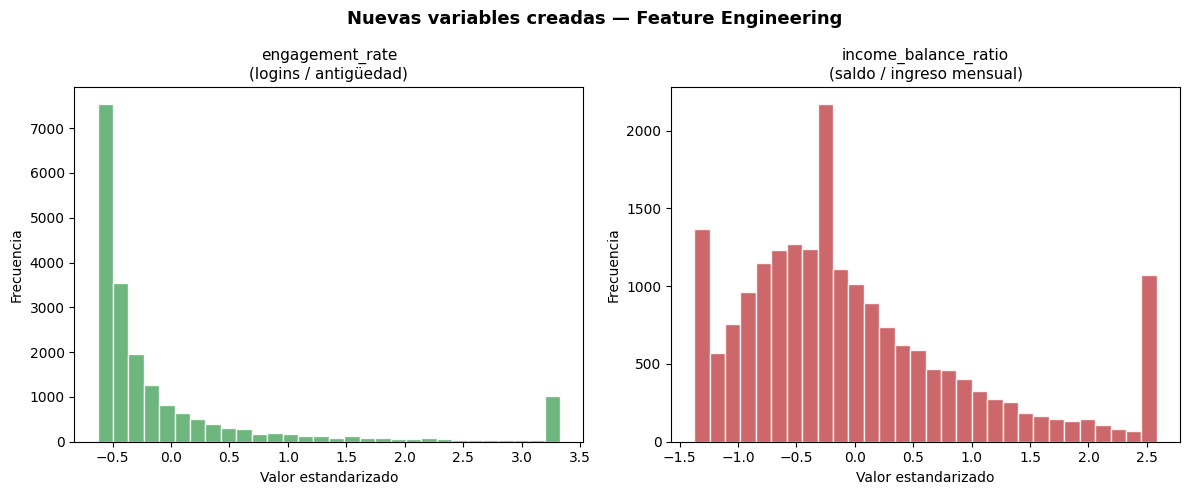

In [58]:
# --- Gráfico 3: Distribución de las nuevas variables (Feature Engineering) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(data_clean['engagement_rate'].dropna(), bins=30,
             color='#55A868', edgecolor='white', alpha=0.85)
axes[0].set_title('engagement_rate\n(logins / antigüedad)', fontsize=11)
axes[0].set_xlabel('Valor estandarizado')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data_clean['income_balance_ratio'].dropna(), bins=30,
             color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].set_title('income_balance_ratio\n(saldo / ingreso mensual)', fontsize=11)
axes[1].set_xlabel('Valor estandarizado')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Nuevas variables creadas — Feature Engineering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Comentario:** Se crearon dos nuevas variables:
- **`engagement_rate`**: mide qué tan activo es el cliente en relación a su antigüedad. Un cliente con alto engagement y baja antigüedad podría indicar un usuario nuevo y comprometido.
- **`income_balance_ratio`**: relaciona el saldo de la cuenta con el ingreso mensual, entregando informacion sobre la capacidad económica del cliente.

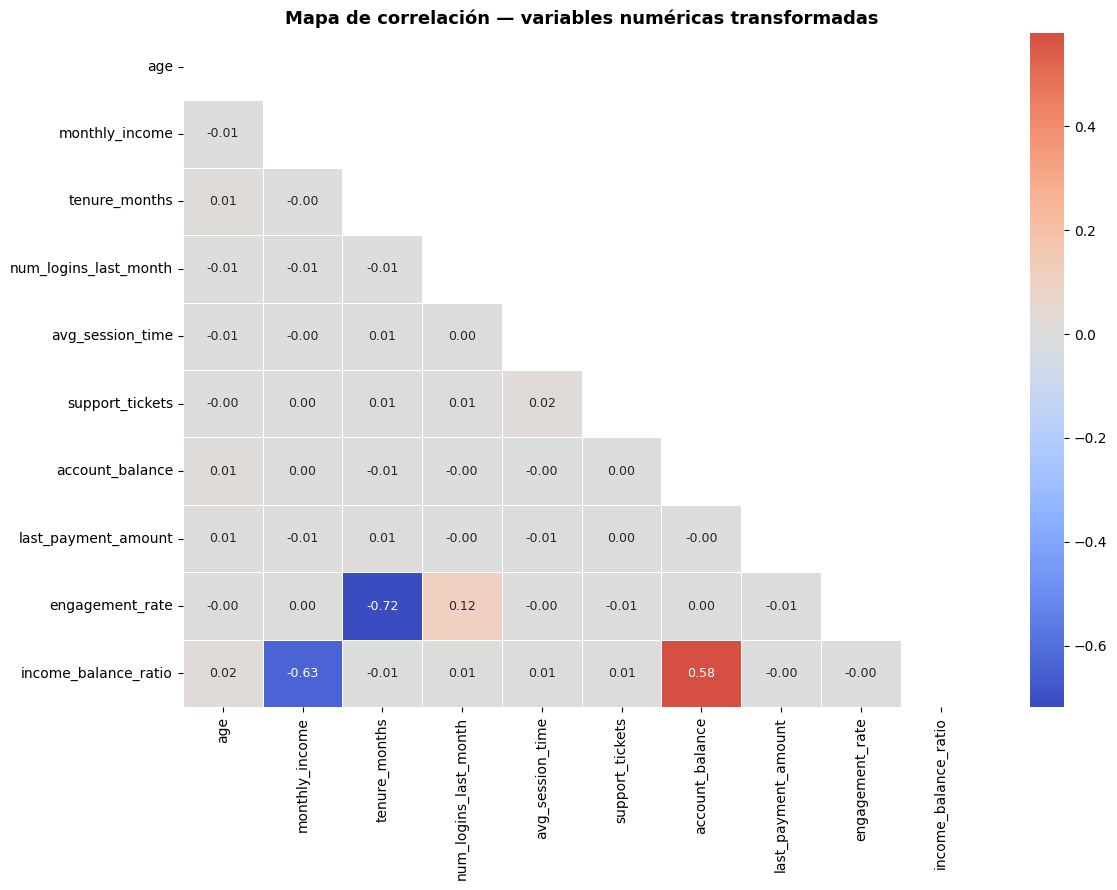

In [69]:
# --- Gráfico 4: Mapa de correlación de variables numéricas transformadas ---
cols_corr = ['age', 'monthly_income', 'tenure_months', 'num_logins_last_month',
             'avg_session_time', 'support_tickets', 'account_balance',
             'last_payment_amount', 'engagement_rate', 'income_balance_ratio']

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = data_clean[cols_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # oculta triángulo superior
sb.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Mapa de correlación — variables numéricas transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Comentario:** El mapa de correlación permite identificar relaciones lineales entre las variables numéricas del dataset transformado.

# Guarda set de datos limpio y transformado

In [60]:
directorio_salida = 'data/cleaned'
os.makedirs(directorio_salida, exist_ok=True)

ruta_archivo = os.path.join(directorio_salida, 'dataset_churn_cleaned.csv')

data_clean.to_csv(ruta_archivo, index=False)

print(f"Dataset limpio guardado en: {ruta_archivo}")
print(f"Dimensiones finales: {data_clean.shape}")

Dataset limpio guardado en: data/cleaned/dataset_churn_cleaned.csv
Dimensiones finales: (20000, 24)
